In [1]:
%load_ext autotime

import scarf

scarf.__version__

'1.0.0'

time: 6.25 s (started: 2026-06-29 18:27:16 +02:00)


In [2]:
scarf.fetch_dataset(
    dataset_name="kang_15K_pbmc_rnaseq", save_path="scarf_datasets", as_zarr=True
)

scarf.fetch_dataset(
    dataset_name="kang_14K_ifnb-pbmc_rnaseq", save_path="scarf_datasets", as_zarr=True
)

time: 34.6 s (started: 2026-06-29 18:27:23 +02:00)


In [3]:
ds_ctrl = scarf.DataStore("scarf_datasets/kang_15K_pbmc_rnaseq/data.zarr/", nthreads=4)

ds_ctrl

DataStore has 8487 (14619) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nFeatures', 'RNA_percentMito', 
            'cluster_labels', 'RNA_leiden_cluster', 'RNA_UMAP2', 'RNA_UMAP1', 'RNA_percentRibo', 
            'RNA_nCounts'
   RNA assay has 11352 (35635) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
            'I__hvgs'

time: 199 ms (started: 2026-06-29 18:27:57 +02:00)


In [4]:
ds_stim = scarf.DataStore(
    "scarf_datasets/kang_14K_ifnb-pbmc_rnaseq/data.zarr", nthreads=4
)

ds_stim

DataStore has 10111 (14446) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_UMAP1', 'RNA_percentMito', 
            'RNA_leiden_cluster', 'RNA_percentRibo', 'RNA_nFeatures', 'cluster_labels', 'RNA_UMAP2', 
            'RNA_nCounts'
   RNA assay has 11051 (35635) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
            'I__hvgs'

time: 195 ms (started: 2026-06-29 18:27:57 +02:00)


In [5]:
scarf.AssayMerge(
    zarr_path="scarf_datasets/kang_merged_pbmc_rnaseq.zarr",
    assays=[ds_ctrl.RNA, ds_stim.RNA],
    names=["ctrl", "stim"],
    merge_assay_name="RNA",
    overwrite=True,
).dump()

Writing data from assay 1/2 to merged file:   0%|                                                             …

Writing data from assay 2/2 to merged file:   0%|                                                             …

time: 13.7 s (started: 2026-06-29 18:27:58 +02:00)


In [6]:
ds = scarf.DataStore("scarf_datasets/kang_merged_pbmc_rnaseq.zarr", nthreads=4)

(RNA) Computing nCells and dropOuts:   0%|                                                                    …

(RNA) Computing nCounts:   0%|                                                                                …

(RNA) Computing nFeatures:   0%|                                                                              …

(RNA) Computing RNA_percentMito:   0%|                                                                        …

(RNA) Computing RNA_percentRibo:   0%|                                                                        …

time: 10.6 s (started: 2026-06-29 18:28:11 +02:00)


In [7]:
ds

DataStore has 29065 (29065) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nFeatures', 'orig_RNA_leiden_cluster', 
            'RNA_percentRibo', 'orig_RNA_percentRibo', 'orig_RNA_nFeatures', 'orig_RNA_UMAP1', 'orig_RNA_nCounts', 
            'RNA_percentMito', 'RNA_nCounts', 'orig_RNA_UMAP2', 'orig_RNA_percentMito', 'orig_cluster_labels', 
          
   RNA assay has 12450 (35635) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

time: 48.9 ms (started: 2026-06-29 18:28:22 +02:00)


In [8]:
ds.cells.head()

,I,ids,names,RNA_nFeatures,orig_RNA_nCounts,RNA_nCounts,orig_RNA_UMAP1,orig_RNA_UMAP2,RNA_percentMito,orig_RNA_nFeatures,RNA_percentRibo,orig_RNA_percentRibo,orig_RNA_leiden_cluster,orig_cluster_labels,orig_RNA_percentMito
0,True,ctrl__TGTTAAGACACTGA-1,TGTTAAGACACTGA-1,304.0,574.0,574.0,NaN,NaN,0.000000,304.0,20.034843,20.034843,-1,nan,0.000000
1,True,ctrl__TCACCCGAGCTATG-1,TCACCCGAGCTATG-1,62.0,1682.0,1682.0,NaN,NaN,0.000000,62.0,0.059453,0.059453,-1,nan,0.000000
2,True,ctrl__TCACCCGAACCACA-1,TCACCCGAACCACA-1,434.0,1168.0,1168.0,-1.768571,-5.990341,0.171233,434.0,31.763699,31.763699,1,CD4 Memory T,0.171233
3,True,ctrl__TGTAGTCTACCAGT-1,TGTAGTCTACCAGT-1,837.0,2158.0,2158.0,-3.052445,-12.830768,0.185357,837.0,32.483781,32.483781,7,CD8 T,0.185357
4,True,ctrl__TATCAGCTAGTAGA-1,TATCAGCTAGTAGA-1,592.0,1395.0,1395.0,-12.654625,-5.425503,0.143369,592.0,34.695341,34.695341,5,B,0.143369


time: 175 ms (started: 2026-06-29 18:28:22 +02:00)


In [9]:
ds.cells.insert(
    column_name="sample_id",
    values=[x.split("__")[0] for x in ds.cells.fetch_all("ids")],
    overwrite=True,
)

time: 36.6 ms (started: 2026-06-29 18:28:22 +02:00)


In [10]:
ctrl_labels = list(ds_ctrl.cells.fetch_all("cluster_labels"))
stim_labels = list(ds_stim.cells.fetch_all("cluster_labels"))

ds.cells.insert(
    column_name="imported_labels", values=ctrl_labels + stim_labels, overwrite=True
)

time: 48.4 ms (started: 2026-06-29 18:28:22 +02:00)


In [11]:
ctrl_valid_cells = list(ds_ctrl.cells.fetch_all("I"))
stim_valid_cells = list(ds_stim.cells.fetch_all("I"))

ds.cells.update_key(values=ctrl_valid_cells + stim_valid_cells, key="I")

time: 36.3 ms (started: 2026-06-29 18:28:22 +02:00)


In [12]:
ds.cells.to_pandas_dataframe(["sample_id"], key="I")["sample_id"].value_counts()

sample_id
ctrl    9441
stim    9157
Name: count, dtype: int64

time: 45 ms (started: 2026-06-29 18:28:22 +02:00)


INFO: Calculating summary statistics


(RNA) Computing feature stats:   0%|                                                                          …

INFO: Calculating HVGs


INFO: 2000 genes marked as HVGs


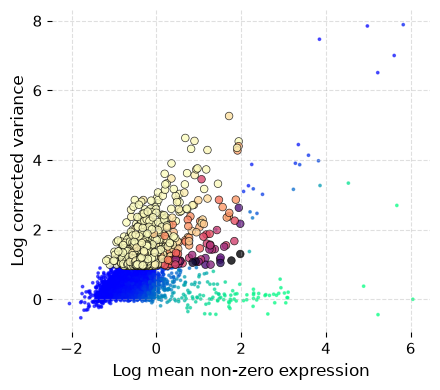

time: 4.5 s (started: 2026-06-29 18:28:22 +02:00)


In [13]:
ds.mark_hvgs(min_cells=10, top_n=2000, min_mean=-3, max_mean=2, max_var=6)

In [14]:
ds.make_graph(feat_key="hvgs", k=21, dims=25, n_centroids=100)

INFO: make_graph step 1/7: normalize expression matrix (computing)


Writing data to normed__I__hvgs/data:   0%|                                                                   …

INFO: make_graph step 1/7: normalize expression matrix finished in 2.5s (computing)


INFO: make_graph step 2/7: normalization statistics (computing)


Calculating mean and std. dev. of norm. data:   0%|                                                           …

...

Smoothening KNN distances:   0%|                                                                              …

INFO: make_graph step 6/7: smooth KNN distances into graph finished in 12.4s (computing)


INFO: make_graph finished in 35.4s (6/7 steps, 35.3s in logged steps)


OSError: [Errno 28] No space left on device

time: 36.2 s (started: 2026-06-29 18:28:27 +02:00)


In [15]:
ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True)

KeyError: 'latest_reduction'

time: 79.6 ms (started: 2026-06-29 18:29:03 +02:00)


In [16]:
ds.cells.head()

,I,ids,names,RNA_percentMito,orig_RNA_UMAP2,sample_id,imported_labels,RNA_nFeatures,orig_RNA_leiden_cluster,RNA_percentRibo,orig_RNA_nFeatures,orig_cluster_labels,orig_RNA_percentRibo,orig_RNA_nCounts,RNA_nCounts,orig_RNA_UMAP1,orig_RNA_percentMito
0,True,ctrl__TGTTAAGACACTGA-1,TGTTAAGACACTGA-1,0.000000,NaN,ctrl,CD4 naive T,304.0,-1,20.034843,304.0,nan,20.034843,574.0,574.0,NaN,0.000000
1,True,ctrl__TCACCCGAGCTATG-1,TCACCCGAGCTATG-1,0.000000,NaN,ctrl,CD 14 Mono,62.0,-1,0.059453,62.0,nan,0.059453,1682.0,1682.0,NaN,0.000000
2,True,ctrl__TCACCCGAACCACA-1,TCACCCGAACCACA-1,0.171233,-5.990341,ctrl,CD 14 Mono,434.0,1,31.763699,434.0,CD4 Memory T,31.763699,1168.0,1168.0,-1.768571,0.171233
3,True,ctrl__TGTAGTCTACCAGT-1,TGTAGTCTACCAGT-1,0.185357,-12.830768,ctrl,CD 14 Mono,837.0,7,32.483781,837.0,CD8 T,32.483781,2158.0,2158.0,-3.052445,0.185357
4,False,ctrl__TATCAGCTAGTAGA-1,TATCAGCTAGTAGA-1,0.143369,-5.425503,ctrl,nan,592.0,5,34.695341,592.0,B,34.695341,1395.0,1395.0,-12.654625,0.143369


time: 348 ms (started: 2026-06-29 18:29:03 +02:00)


In [17]:
ds.plot_layout(
    layout_key="RNA_UMAP", color_by="sample_id", cmap="RdBu", legend_ondata=False
)

KeyError: 'RNA_UMAP1 does not exist in the metadata columns.'

time: 216 ms (started: 2026-06-29 18:29:04 +02:00)


In [18]:
ds.plot_layout(layout_key="RNA_UMAP", color_by="imported_labels", legend_ondata=False)

KeyError: 'RNA_UMAP1 does not exist in the metadata columns.'

time: 98.6 ms (started: 2026-06-29 18:29:04 +02:00)


In [19]:
ds.cells.insert(
    column_name="is_ctrl",
    values=(ds.cells.fetch_all("sample_id") == "ctrl"),
    overwrite=True,
)

time: 41.1 ms (started: 2026-06-29 18:29:04 +02:00)


In [20]:
ds.make_graph(feat_key="hvgs", k=21, dims=25, n_centroids=100, pca_cell_key="is_ctrl")

INFO: make_graph step 1/7: normalize expression matrix (reusing cached)


INFO: Using existing normalized data with cell key I and feat key I__hvgs


INFO: make_graph step 1/7: normalize expression matrix finished in 0.1s (reusing cached)


INFO: make_graph step 2/7: normalization statistics (reusing cached)


INFO: make_graph step 2/7: normalization statistics finished in 0.0s (reusing cached)


...

INFO: ANN recall: 99.87%


INFO: make_graph step 7/7: finalize graph metadata (computing)


INFO: make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)


INFO: make_graph finished in 14.2s (7/7 steps, 14.1s in logged steps)


time: 14.3 s (started: 2026-06-29 18:29:04 +02:00)


In [21]:
ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True, label="pUMAP")

Training UMAP:   0%|                                                                                          …

time: 7.66 s (started: 2026-06-29 18:29:18 +02:00)


/home/parashar/scarf/scarf/metadata.py:344: RuntimeWarning: overflow encountered in cast
  a = np.empty(self.N).astype(values.dtype)


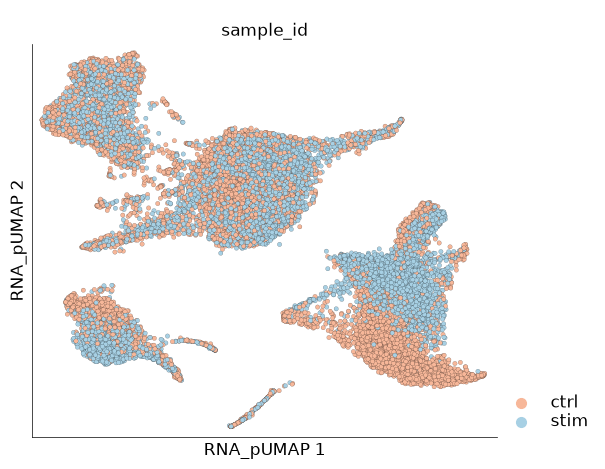

time: 579 ms (started: 2026-06-29 18:29:26 +02:00)


In [22]:
ds.plot_layout(
    layout_key="RNA_pUMAP", color_by="sample_id", cmap="RdBu", legend_ondata=False
)

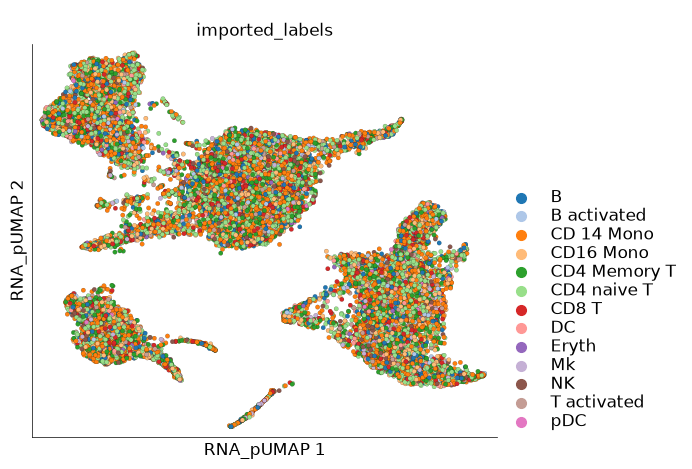

time: 403 ms (started: 2026-06-29 18:29:27 +02:00)


In [23]:
ds.plot_layout(layout_key="RNA_pUMAP", color_by="imported_labels", legend_ondata=False)

In [24]:
ds.make_graph(
    feat_key="hvgs",
    k=21,
    dims=25,
    n_centroids=100,
    harmonize=True,
    batch_columns=["sample_id"],
)

ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True, label="hUMAP")

ds.run_leiden_clustering(resolution=1.0)

INFO: make_graph step 1/7: normalize expression matrix (reusing cached)


INFO: Using existing normalized data with cell key I and feat key I__hvgs


INFO: make_graph step 1/7: normalize expression matrix finished in 0.1s (reusing cached)


INFO: make_graph step 2/7: normalization statistics (reusing cached)


INFO: make_graph step 2/7: normalization statistics finished in 0.0s (reusing cached)


...

INFO: make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)


INFO: make_graph finished in 20.6s (7/7 steps, 20.5s in logged steps)


Training UMAP:   0%|                                                                                          …

/home/parashar/scarf/scarf/metadata.py:344: RuntimeWarning: overflow encountered in cast
  a = np.empty(self.N).astype(values.dtype)


time: 31.4 s (started: 2026-06-29 18:29:27 +02:00)


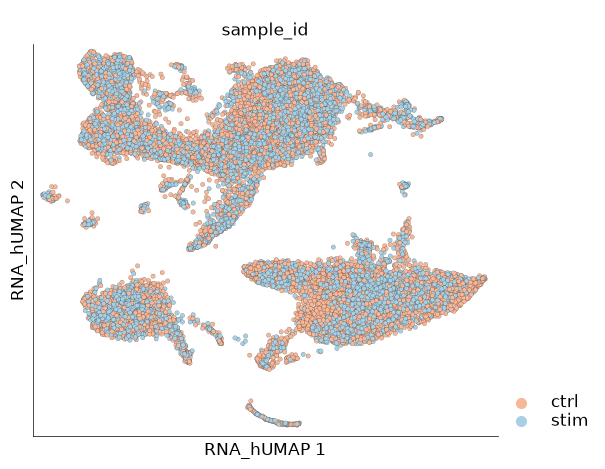

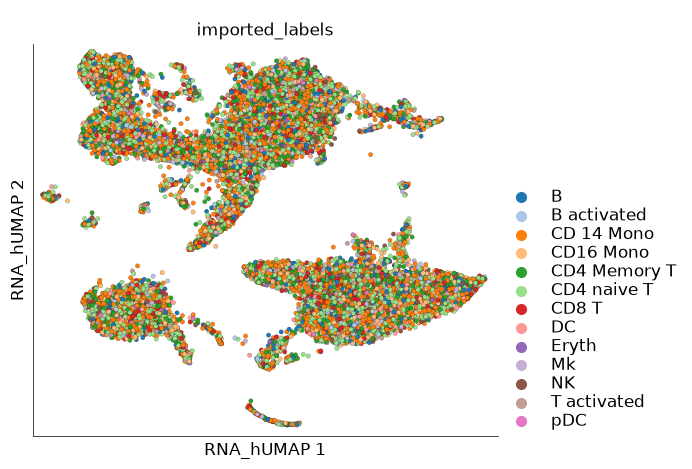

time: 934 ms (started: 2026-06-29 18:29:58 +02:00)


In [25]:
ds.plot_layout(
    layout_key="RNA_hUMAP", color_by="sample_id", cmap="RdBu", legend_ondata=False
)

ds.plot_layout(layout_key="RNA_hUMAP", color_by="imported_labels", legend_ondata=False)

In [26]:
ds.metric_lisi(
    label_colnames=["sample_id", "imported_labels"],
    save_result=True,
)

ds.metric_silhouette(res_label="RNA_leiden_cluster")

ds.metric_integration(batch_labels=["sample_id", "imported_labels"], metric="ari")

INFO: Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__is_ctrl/ann__l2__63__63__48__4466/knn__21


INFO: Computing LISI for sample_id


Computing Simpson's Diversity Index:   0%|                                                                    …

INFO: Computing LISI for imported_labels


Computing Simpson's Diversity Index:   0%|                                                                    …

INFO: Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__is_ctrl/ann__l2__63__63__48__4466/knn__21 for assay: RNA


INFO: Loaded existing ANN stream from RNA/normed__I__hvgs/reduction__pca__25__is_ctrl/ann__l2__63__63__48__4466


ERROR: Cluster labels not found for RNA_RNA_leiden_cluster


-3.705291026995729e-06

time: 19.6 s (started: 2026-06-29 18:29:59 +02:00)
